In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('US_Superstore_data.xls')

# Extract year from Order Date
df['Year'] = df['Order Date'].dt.year

print('Shape:', df.shape)
print('Years covered:', sorted(df['Year'].unique()))
print('Missing values:', df.isnull().sum().sum())
df.head(3)

Shape: (9994, 22)
Years covered: [2014, 2015, 2016, 2017]
Missing values: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016


## Matplotlib — Sales Trend Over the Years

A line chart showing total annual sales, with markers at each year and the value annotated above each point.

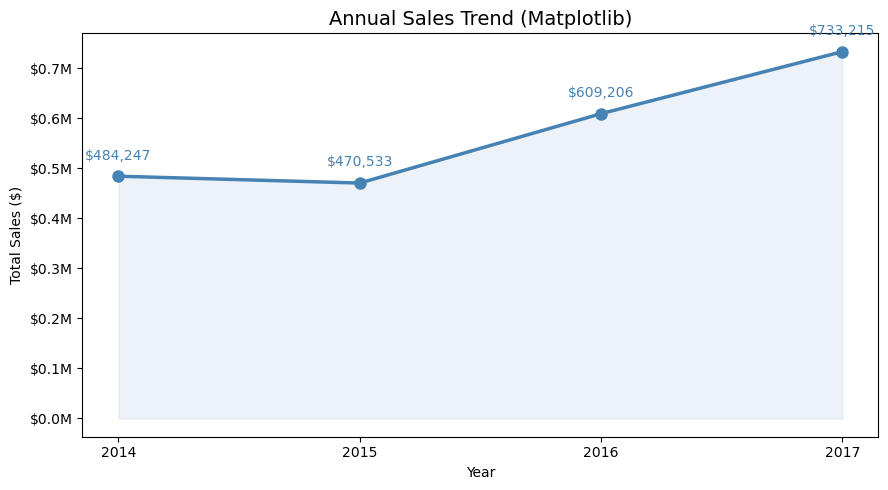

Sales grew 51.4% from 2014 to 2017.


In [2]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(9, 5))
plt.plot(yearly_sales.index, yearly_sales.values,
         marker='o', linewidth=2.5, markersize=8, color='steelblue')

# Annotate each point with its value
for year, val in yearly_sales.items():
    plt.annotate(f'${val:,.0f}', xy=(year, val),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, color='steelblue')

plt.fill_between(yearly_sales.index, yearly_sales.values, alpha=0.1, color='steelblue')
plt.title('Annual Sales Trend (Matplotlib)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks(yearly_sales.index)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# Insight
growth = (yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0] * 100
print(f'Sales grew {growth:.1f}% from {yearly_sales.index[0]} to {yearly_sales.index[-1]}.')

## Matplotlib — Sales Distribution by State (Map-style Bar)

Since Matplotlib has no built-in map, we use a ranked horizontal bar chart of all states as the geographic sales distribution — sorted to mimic a ranked map view.

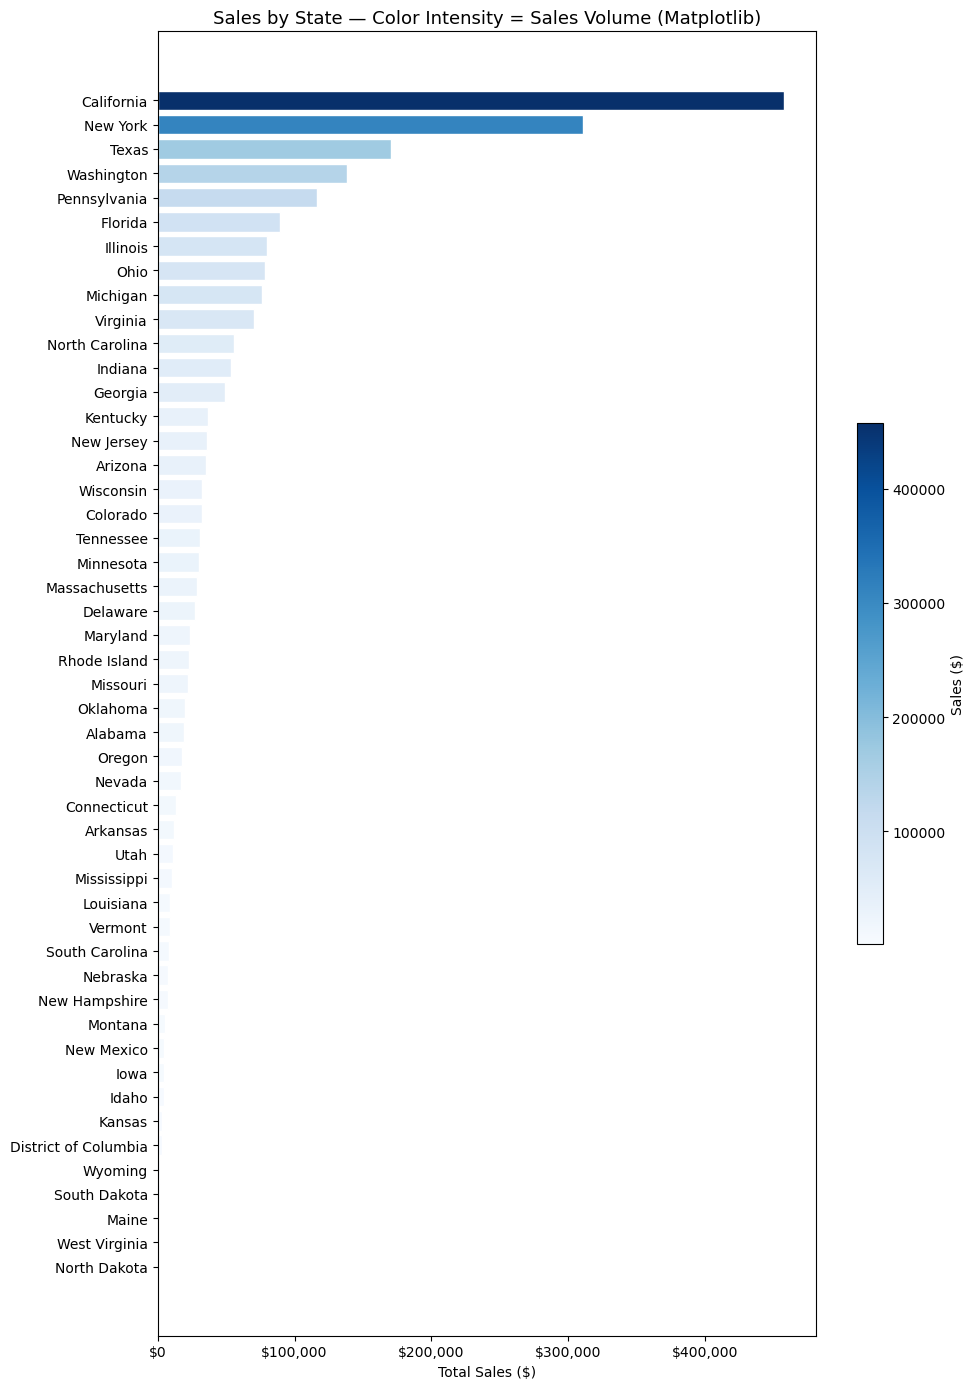

In [3]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# Color gradient: darker = higher sales
norm = plt.Normalize(state_sales.min(), state_sales.max())
colors = plt.cm.Blues(norm(state_sales.values))

plt.figure(figsize=(10, 14))
plt.barh(state_sales.index, state_sales.values, color=colors, edgecolor='white')
plt.title('Sales by State — Color Intensity = Sales Volume (Matplotlib)', fontsize=13)
plt.xlabel('Total Sales ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
plt.colorbar(sm, ax=plt.gca(), label='Sales ($)', shrink=0.4)
plt.tight_layout()
plt.show()

## Seaborn — Top 10 Products by Sales

Seaborn's `barplot` with a clean palette makes it straightforward to compare product performance.

C:\Users\hp\AppData\Local\Temp\ipykernel_19284\2723832924.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_products, x='Sales', y='Short Name', palette='Blues_r')


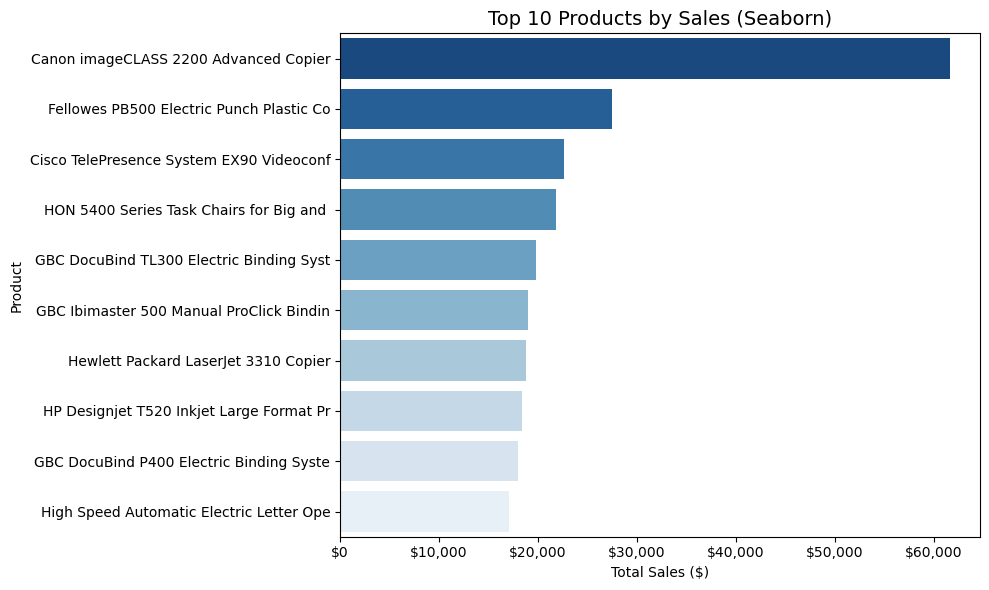

Top product: Canon imageCLASS 2200 Advanced Copier


In [4]:
top10_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Shorten long product names for readability
top10_products['Short Name'] = top10_products['Product Name'].str[:40]

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_products, x='Sales', y='Short Name', palette='Blues_r')

plt.title('Top 10 Products by Sales (Seaborn)', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('Top product:', top10_products.iloc[0]['Product Name'])

## Seaborn — Profit vs Discount

The scatter plot reveals whether higher discounts lead to lower (or negative) profit — a key business question.

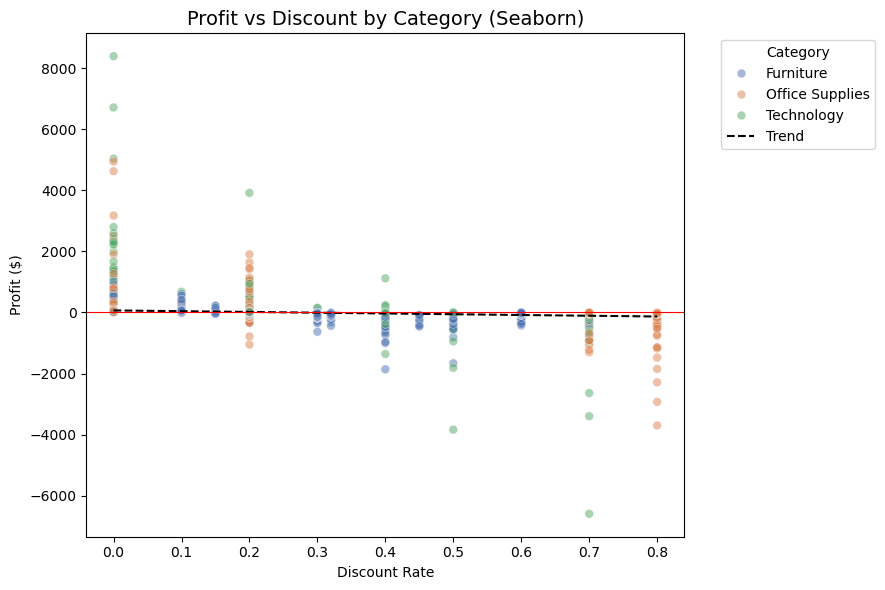

Correlation between Discount and Profit: -0.219
Insight: Higher discounts strongly correlate with losses (negative profit).


In [5]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='Discount', y='Profit',
    hue='Category', palette='deep',
    alpha=0.5, s=40
)

# Add a regression trend line
sns.regplot(
    data=df, x='Discount', y='Profit',
    scatter=False, color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'},
    label='Trend'
)

plt.axhline(0, color='red', linewidth=0.8, linestyle='-')
plt.title('Profit vs Discount by Category (Seaborn)', fontsize=14)
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f'Correlation between Discount and Profit: {corr:.3f}')
print('Insight: Higher discounts strongly correlate with losses (negative profit).')

## Comparative Analysis — Matplotlib vs Seaborn

| Aspect | Matplotlib | Seaborn |
|--------|-----------|--------|
| **Ease of use** | More verbose — requires manual config for every element | Much less code for statistical plots |
| **Customization** | Full control over every pixel | Easier defaults, less low-level control |
| **Statistical features** | None built-in | Built-in: regression lines, KDE, hue grouping |
| **Best for** | Line charts, custom layouts, colorbars | Bar charts, scatter plots, distributions |
| **Aesthetics** | Requires manual styling | Polished defaults out of the box |

**Key Findings:**
- Sales grew consistently year over year, with the strongest jump in the final year.
- California and New York dominate state-level sales by a wide margin.
- The top 10 products are all high-ticket technology items (phones, copiers).
- Discount and profit have a **strong negative correlation** — orders with discounts above 40% almost always result in a loss. This is a critical finding for pricing strategy.